# Cylinder mesh tallies

In addition to regular meshes seen in part 1 and 2 meshes can also be defined in a variety of shapes include cylinder and sphere

This notebook allows users to create a highly simplified geometry based on the first light fusion reactor design (more details here https://www.youtube.com/watch?v=aW4eufacf-8) and tally tritium production on a cylindrical mesh.

This first code block defines the model geometry and materials.

First import OpenMC and configure the nuclear data path

In [1]:
import openmc
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

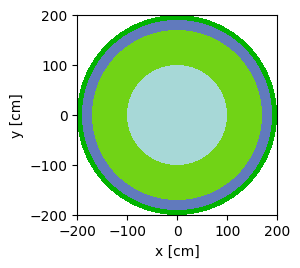

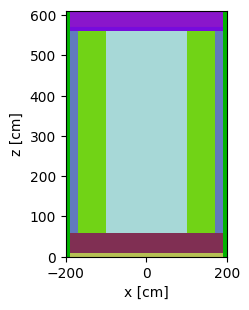

In [2]:
import openmc

inner_blanket_radius = 100.
blanket_thickness = 70.
blanket_height = 500.
lower_blanket_thickness = 50.
upper_blanket_thickness = 40.
blanket_vv_gap = 20.
upper_vv_thickness = 10.
vv_thickness = 10.
lower_vv_thickness = 10.


mat_vessel_cell_lower = openmc.Material()
mat_vessel_cell_upper = openmc.Material()
mat_vessel_cell_cylinder = openmc.Material()
mat_blanket_cell_cylinder = openmc.Material()
mat_blanket_cell_upper = openmc.Material()
mat_blanket_cell_lower = openmc.Material()

for mat in [mat_vessel_cell_lower, mat_vessel_cell_upper, mat_vessel_cell_cylinder]:
    mat.add_element("Fe", 89)
    mat.add_element("Cr", 9.1)
    mat.add_element("Mo", 1)
    mat.add_element("Mn", 0.5)
    mat.add_element("Si", 0.4)
    mat.set_density("g/cm3", 7.96)

for mat in [mat_blanket_cell_cylinder, mat_blanket_cell_upper, mat_blanket_cell_lower]:
    mat.add_element("Li", 100)
    mat.set_density("g/cm3", 0.5)

my_materials = openmc.Materials(
    [
        mat_vessel_cell_lower,
        mat_vessel_cell_upper,
        mat_vessel_cell_cylinder,
        mat_blanket_cell_cylinder,
        mat_blanket_cell_upper,
        mat_blanket_cell_lower,
    ]
)

# surfaces
inner_blanket_cylinder = openmc.ZCylinder(r=inner_blanket_radius)
outer_blanket_cylinder = openmc.ZCylinder(r=inner_blanket_radius + blanket_thickness)

inner_vessel_cylinder = openmc.ZCylinder(
    r=inner_blanket_radius + blanket_thickness + blanket_vv_gap
)
outer_vessel_cylinder = openmc.ZCylinder(
    r=inner_blanket_radius + blanket_thickness + blanket_vv_gap + vv_thickness,
    boundary_type="vacuum",
)

upper_vessel_bottom = openmc.ZPlane(
    z0=blanket_height + lower_vv_thickness + lower_blanket_thickness
)
upper_vessel_top = openmc.ZPlane(
    z0=blanket_height
    + lower_vv_thickness
    + lower_blanket_thickness
    + upper_vv_thickness
)

lower_blanket_top = openmc.ZPlane(z0=lower_vv_thickness + lower_blanket_thickness)
lower_blanket_bottom = openmc.ZPlane(z0=lower_vv_thickness)

upper_blanket_bottom = upper_vessel_top
upper_blanket_top = openmc.ZPlane(
    z0=blanket_height
    + lower_vv_thickness
    + lower_blanket_thickness
    + upper_vv_thickness
    + upper_blanket_thickness,
    boundary_type="vacuum",
)

lower_vessel_top = lower_blanket_bottom
lower_vessel_bottom = openmc.ZPlane(z0=0, boundary_type="vacuum")

# regions
inner_void_region = -upper_vessel_bottom & +lower_blanket_top & -inner_blanket_cylinder
blanket_region = (
    -upper_vessel_bottom
    & +lower_blanket_top
    & +inner_blanket_cylinder
    & -outer_blanket_cylinder
)

blanket_upper_region = (
    -inner_vessel_cylinder & -upper_blanket_top & +upper_blanket_bottom
)
blanket_lower_region = (
    -inner_vessel_cylinder & -lower_blanket_top & +lower_blanket_bottom
)

outer_void_region = (
    -upper_vessel_bottom
    & +lower_blanket_top
    & -inner_vessel_cylinder
    & +outer_blanket_cylinder
)

vessel_region = (
    -upper_blanket_top
    & +lower_vessel_bottom
    & -outer_vessel_cylinder
    & +inner_vessel_cylinder
)
vessel_upper_region = -upper_vessel_top & +upper_vessel_bottom & -inner_vessel_cylinder
vessel_lower_region = -lower_vessel_top & +lower_vessel_bottom & -inner_vessel_cylinder

# cells
vessel_cell_lower = openmc.Cell(region=vessel_lower_region)
vessel_cell_upper = openmc.Cell(region=vessel_upper_region)
vessel_cell_cylinder = openmc.Cell(region=vessel_region)
vessel_cell_lower.fill = mat_vessel_cell_lower
vessel_cell_upper.fill = mat_vessel_cell_upper
vessel_cell_cylinder.fill = mat_vessel_cell_cylinder

blanket_cell_cylinder = openmc.Cell(region=blanket_region)
blanket_cell_upper = openmc.Cell(region=blanket_upper_region)
blanket_cell_lower = openmc.Cell(region=blanket_lower_region)
blanket_cell_cylinder.fill = mat_blanket_cell_cylinder
blanket_cell_upper.fill = mat_blanket_cell_upper
blanket_cell_lower.fill = mat_blanket_cell_lower

void_cell1 = openmc.Cell(region=inner_void_region)
void_cell2 = openmc.Cell(region=outer_void_region)

my_geometry = openmc.Geometry([
        void_cell1,
        void_cell2,
        vessel_cell_lower,
        vessel_cell_upper,
        vessel_cell_cylinder,
        blanket_cell_cylinder,
        blanket_cell_upper,
        blanket_cell_lower,
    ])

my_geometry.plot(basis='xy')
my_geometry.plot(basis='xz')

This code block defines the neutron plasma source.

In [3]:
max_source_height = blanket_height + lower_vv_thickness + lower_blanket_thickness
min_source_height = lower_vv_thickness + lower_blanket_thickness
range_of_source_heights = max_source_height - min_source_height
# 0.5 is fractional_height_of_source
absolute_height_of_source = (0.5 * range_of_source_heights) + min_source_height

# initialises a new source object
my_source = openmc.IndependentSource()

# sets the location of the source to x=0 y=0 z=0
my_source.space = openmc.stats.Point((0, 0, absolute_height_of_source))

# sets the direction to isotropic
my_source.angle = openmc.stats.Isotropic()

# sets the energy distribution to 100% 14MeV neutrons
my_source.energy = openmc.stats.Discrete([14e6], [1])


my_settings = openmc.Settings()
my_settings.inactive = 0
my_settings.run_mode = "fixed source"
my_settings.batches = 10
my_settings.particles = 10000
my_settings.source = my_source

This code block creates a 3D regular mesh between two coordinates with a specified resolution in each axis.

In [4]:
# Create mesh which will be used for tally
import numpy as np
mesh = openmc.CylindricalMesh.from_domain(
    domain=my_geometry, # the corners of the mesh are being set automatically to surround the geometry
    dimension=[10, 20, 30] # 100 voxels in each axis direction (r, z, phi)
)

This code block creates two tallies on the mesh to record heating and tritium production.

In [5]:
my_tallies = openmc.Tallies()
# Create mesh filter for tally
mesh_filter = openmc.MeshFilter(mesh)

# Create mesh tally to score tritium production
mesh_tally_1 = openmc.Tally(name='tbr_on_mesh')
mesh_tally_1.filters = [mesh_filter]
mesh_tally_1.scores = ['(n,Xt)']  # where X is a wildcard
my_tallies.append(mesh_tally_1)

# Create mesh tally to score heating
mesh_tally_2 = openmc.Tally(name='heating_on_mesh')
mesh_tally_2.filters = [mesh_filter]
mesh_tally_2.scores = ['heating']
my_tallies.append(mesh_tally_2)

This next code block performs the simulation.

In [6]:
# deletes old statepoint and summary files
!rm s*.h5

# Run OpenMC!
model = openmc.model.Model(my_geometry, my_materials, my_settings, my_tallies)
sp_filename = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5


 Reading Fe57 from /home/jon/nuclear_data/neutron/Fe57.h5


 Reading Fe58 from /home/jon/nuclear_data/neutron/Fe58.h5


 Reading Cr50 from /home/jon/nuclear_data/neutron/Cr50.h5
 Reading Cr52 from /home/jon/nuclear_data/neutron/Cr52.h5
 Reading Cr53 from /home/jon/nuclear_data/neutron/Cr53.h5


...

 Simulating batch 3
 Simulating batch 4


 Simulating batch 5


 Simulating batch 6
 Simulating batch 7


 Simulating batch 8
 Simulating batch 9


 Simulating batch 10
 Creating state point statepoint.10.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 3.0669e+00 seconds
   Reading cross sections          = 3.0374e+00 seconds
 Total time in simulation          = 1.6501e+00 seconds
   Time in transport only          = 1.5756e+00 seconds
   Time in active batches          = 1.6501e+00 seconds
   Time accumulating tallies       = 5.1738e-02 seconds
   Time writing statepoints        = 2.0054e-02 seconds
 Total time for finalization       = 3.5929e-02 seconds
 Total time elapsed                = 4.7706e+00 seconds
 Calculation Rate (active)         = 60604.2 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.37437 +/- 0.00239



This code block runs a python function which extracts the mesh tally data from the statepoint.h5 file and saves it as a vtk file.

In [7]:
# loads up the output file from the simulation
statepoint = openmc.StatePoint(sp_filename)

# extracts the mesh tally by name
my_tbr_tally = statepoint.get_tally(name='tbr_on_mesh')

# converts the tally result into a VTK file
mesh.write_data_to_vtk(
    filename="tbr_tally_on_cy_mesh.vtk",
    datasets={"mean": my_tbr_tally.mean}  # the first "mean" is the name of the data set label inside the vtk file
)

# extracts the mesh tally by name
my_heating_tally = statepoint.get_tally(name='heating_on_mesh')

# converts the tally result into a VTK file
# this time standard deviation error on the tally is added to the vtk file as another data set
# the tally is also scaled from eV per source particle to Joules per source particle 1eV = 1.60218e-19J)
# Try adding another scaling term to multiplying by the number of neutrons emitted per second would which would convert the units to Watts
mesh.write_data_to_vtk(
    filename="heating_tally_on_cy_mesh.vtk",
    datasets={"mean": my_heating_tally.mean * 1.60218e-19, "std_dev": my_heating_tally.std_dev * 1.60218e-19}
)

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mesh.py:1877: UserWarning: Cartesian coordinates are returned from this property as of version 0.14.0
  warnings.warn('Cartesian coordinates are returned from this property as of version 0.14.0')


<StructuredGrid(0x5c5ba389ed70) at 0x76080ef6f700>

Click on the newly created vtk file in the file explorer to the left and download the vtk files onto your base computer and open them with a VTK file reader such as Paraview or Visit.

Paraview can be downloaded here: https://www.paraview.org/download/.
Visit can be downloaded here: https://wci.llnl.gov/simulation/computer-codes/visit/downloads.

**Learning Outcomes for Part 3:**

- Mesh tallies can be different shapes, this can be chosen to match the underlying geometry.